In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## Regression To Classification, Logistic Regression

### Cell 1: 라이브러리 및 데이터 로드

In [29]:
# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# 3. 파생 변수 생성 (정지 상태 판단)
speed_cols = ['Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5']
df_clean['is_stationary'] = (df_clean[speed_cols].abs().sum(axis=1) < 0.05).astype(int)

# 4. 입력 피처(X) 설정
input_cols = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5',
    'is_stationary'
]
X = df_clean[input_cols]

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개")

데이터 크기: (7355, 25)
피처 개수: 13개


### Cell 2: 타겟 변수 라벨링

In [30]:
# 연속형 Tool_current 값을 3개의 물리적 상태 범주로 변환하는 함수
def categorize_current(val):
    if val < 0.12:
        return 0  # 대기 상태 (Standby)
    elif val < 0.35:
        return 1  # 전이 상태 (Transition)
    else:
        return 2  # 파지 상태 (Gripping)
    #else:
        return 1  # 파지 상태 (Gripping)
    

# 새로운 범주형 타겟(y) 생성
y = df_clean['Tool_current'].apply(categorize_current)

print("분류된 타겟(y)의 클래스별 데이터 개수:")
print(y.value_counts().sort_index())

분류된 타겟(y)의 클래스별 데이터 개수:
Tool_current
0    6337
1     756
2     262
Name: count, dtype: int64


### Cell 3: 데이터 분할 및 스케일링

In [31]:
# 1. Train / Test Split (클래스 비율을 유지하기 위해 stratify=y 적용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. 데이터 스케일링 (로지스틱 회귀는 변수 스케일에 민감함)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터 크기: {X_train_scaled.shape}")
print(f"테스트 데이터 크기: {X_test_scaled.shape}")

학습 데이터 크기: (5884, 13)
테스트 데이터 크기: (1471, 13)


### Cell 4: Logistic Regression 학습 및 하이퍼파라미터 튜닝

In [32]:
# 1. Stratified K-Fold 설정 (클래스 비율 유지)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. 로지스틱 회귀 기본 모델 생성 (데이터 불균형 해결을 위해 class_weight='balanced' 필수)
log_reg = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)

# 3. 튜닝할 파라미터 그리드 (규제 강도 C와 페널티 종류 설정)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],           # 규제 강도 (작을수록 규제가 강함)
    'penalty': ['l1', 'l2'],                # L1(Lasso 성격), L2(Ridge 성격) 규제
    'solver': ['saga']                      #L1/L2 모두 지원하는 최적화 알고리즘
}

# 4. GridSearchCV 실행 (데이터 불균형을 고려해 scoring을 'f1_macro'로 설정)
print("--- Logistic Regression 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search_lr = GridSearchCV(
    estimator=log_reg, 
    param_grid=param_grid, 
    cv=skf, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_scaled, y_train)

# 5. 최적 파라미터 및 결과 확인
print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search_lr.best_params_.items():
    print(f"  • {param}: {value}")
print("")
print(f"최고 교차 검증 F1-Macro 점수: {grid_search_lr.best_score_:.4f}")

--- Logistic Regression 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • C: 1
  • penalty: l2
  • solver: saga

최고 교차 검증 F1-Macro 점수: 0.4887


### Cell 5: 상위 10개 모델 비교 데이터프레임 & 최종 평가

In [33]:
# 1. GridSearchCV 결과에서 상위 10개 모델 추출
cv_results_df = pd.DataFrame(grid_search_lr.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

# 비교 결과를 담을 리스트
comparison_data = []

print("--- [모델 비교] 상위 10개 Logistic Regression 성능 종합 ---")

# 2. 상위 모델들을 하나씩 돌려가며 Train/Test 평가 진행
for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_f1 = row['mean_test_score']
    
    # 해당 파라미터로 모델 재학습
    model = LogisticRegression(**params, random_state=42, class_weight='balanced', max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # 평가지표 계산 (분류에서는 R2 대신 F1-Macro와 Accuracy 사용)
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # 파라미터 설정을 간소화된 문자열로 변환 (예: C=10, P=l2, S=liblinear)
    c_val = params.get('C', '-')
    pen_val = params.get('penalty', '-')
    sol_val = params.get('solver', '-')
    param_short = f"C={c_val}, P={pen_val}, S={sol_val}"
    
    # 결과 저장 (과적합 정도를 보기 위해 Train F1 - Test F1 Gap 추가)
    comparison_data.append({
        '순위': rank,
        'CV F1': round(cv_f1, 4),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        '과적합 Gap': round(train_f1 - test_f1, 4), 
        'Train Acc': round(train_acc, 6),
        'Test Acc': round(test_acc, 6),
        '파라미터 설정': param_short
    })

# 3. 비교 결과를 데이터프레임으로 출력 (Jupyter에서 표 형태로 예쁘게 출력됨)
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

--- [모델 비교] 상위 10개 Logistic Regression 성능 종합 ---


,순위,CV F1,Train F1,Test F1,과적합 Gap,Train Acc,Test Acc,파라미터 설정
0,1,0.4887,0.4830,0.4567,0.0263,0.657206,0.662135,"C=1, P=l2, S=saga"
1,2,0.4876,0.4869,0.4599,0.0270,0.660095,0.665534,"C=10, P=l2, S=saga"
2,3,0.4871,0.4879,0.4592,0.0287,0.661455,0.665534,"C=100, P=l1, S=saga"
3,4,0.4870,0.4874,0.4589,0.0285,0.660775,0.664854,"C=10, P=l1, S=saga"
4,5,0.4867,0.4879,0.4593,0.0286,0.661455,0.665534,"C=100, P=l2, S=saga"
5,6,0.4857,0.4862,0.4594,0.0268,0.659925,0.664174,"C=1, P=l1, S=saga"
6,7,0.4774,0.4798,0.4555,0.0242,0.649388,0.655337,"C=0.1, P=l2, S=saga"
7,8,0.4731,0.4751,0.4541,0.0210,0.642930,0.647179,"C=0.1, P=l1, S=saga"
8,9,0.4587,0.4631,0.4420,0.0211,0.609619,0.616587,"C=0.01, P=l2, S=saga"
9,10,0.4447,0.4504,0.4406,0.0098,0.564072,0.585996,"C=0.01, P=l1, S=saga"


### Cell 6: 특정 순위 모델 최종 평가지표 상세 분석

In [36]:
print("\n" + "="*50)
target_rank = 2  # 분석하고 싶은 순위를 여기에 입력하세요 (예: 1, 2, 3...)
print(f"--- [상세 분석] {target_rank}위 모델 최종 평가지표 ---")
print("="*50)

# 1. Cell 5-2에서 생성된 top_models에서 원하는 순위의 파라미터 추출
# 중복 순위가 있을 수 있으므로 첫 번째(.iloc[0]) 모델을 가져옵니다.
selected_row = top_models[top_models['rank_test_score'] == target_rank].iloc[0]
selected_params = selected_row['params']

print(f"\n[선택된 {target_rank}위 모델의 하이퍼파라미터]")
for param, value in selected_params.items():
    print(f"  • {param}: {value}")

# 2. 추출한 파라미터로 모델 재학습
selected_lr = LogisticRegression(**selected_params, random_state=42, class_weight='balanced', max_iter=1000)
selected_lr.fit(X_train_scaled, y_train)

# 3. 예측 수행
y_train_pred_selected = selected_lr.predict(X_train_scaled)
y_test_pred_selected = selected_lr.predict(X_test_scaled)

# 4. 평가지표 출력 함수
def print_metrics(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"Accuracy (정확도) : {acc:.4f}")
    print(f"F1-Macro Score    : {f1_macro:.6f}")
    
    print(f"\n[{dataset_name} 상세 분류 리포트]")
    print(classification_report(y_true, y_pred, target_names=['0 (Standby)', '1 (Transition)', '2 (Gripping)']))

# 5. Train / Test 결과 출력
print_metrics(y_train, y_train_pred_selected, "Train")
print_metrics(y_test, y_test_pred_selected, "Test")

# Cell 7에서 선택된 모델의 오차 행렬(Confusion Matrix)이 그려지도록 변수 연결
y_test_pred = y_test_pred_selected


--- [상세 분석] 2위 모델 최종 평가지표 ---

[선택된 2위 모델의 하이퍼파라미터]
  • C: 10
  • penalty: l2
  • solver: saga

[Train 데이터 평가]
Accuracy (정확도) : 0.6601
F1-Macro Score    : 0.486929

[Train 상세 분류 리포트]
                precision    recall  f1-score   support

   0 (Standby)       0.97      0.65      0.78      5070
1 (Transition)       0.24      0.77      0.37       605
  2 (Gripping)       0.22      0.57      0.31       209

      accuracy                           0.66      5884
     macro avg       0.48      0.66      0.49      5884
  weighted avg       0.87      0.66      0.72      5884


[Test 데이터 평가]
Accuracy (정확도) : 0.6655
F1-Macro Score    : 0.459895

[Test 상세 분류 리포트]
                precision    recall  f1-score   support

   0 (Standby)       0.97      0.66      0.79      1267
1 (Transition)       0.26      0.80      0.39       151
  2 (Gripping)       0.14      0.36      0.20        53

      accuracy                           0.67      1471
     macro avg       0.46      0.61      0.46      14

### Cell 7: 오차 행렬(Confusion Matrix) 시각화

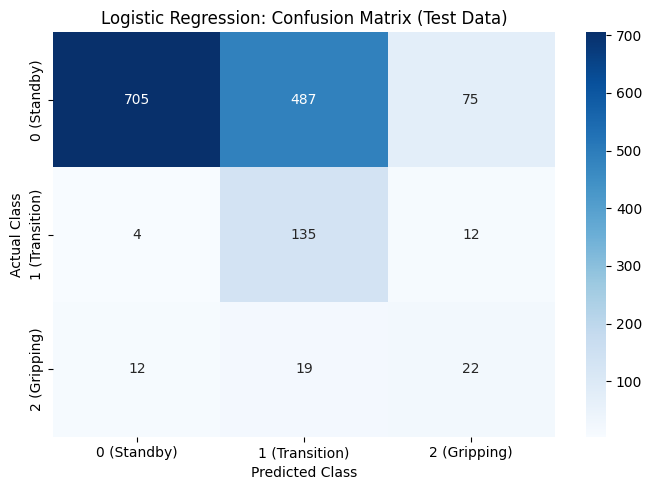

In [14]:
# 분류 모델의 예측 결과를 눈으로 확인하기 위한 오차 행렬 시각화
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['0 (Standby)', '1 (Transition)', '2 (Gripping)'],
            yticklabels=['0 (Standby)', '1 (Transition)', '2 (Gripping)'])

plt.title('Logistic Regression: Confusion Matrix (Test Data)')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()